<a href="https://colab.research.google.com/github/sanjanasrinivas22/6thSem-ML-Lab/blob/main/1BM23CS301_Lab9_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best Estimators = 80
Accuracy = 0.8334527587265841


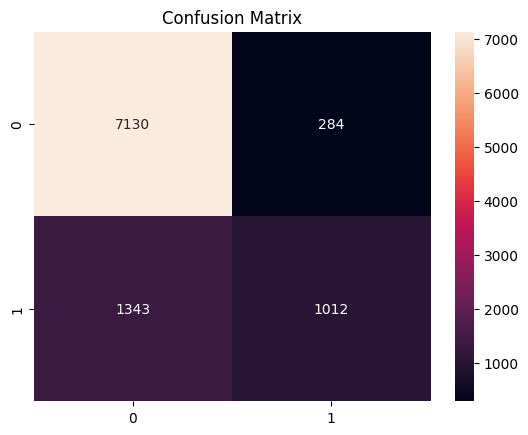

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("income.csv")      # Upload dataset here

X = pd.get_dummies(df.iloc[:, :-1])
y = df.iloc[:, -1]

le = LabelEncoder()
y = le.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

best_score = 0
best_est = 0

for n in range(10,101,10):
    model = AdaBoostClassifier(n_estimators=n,random_state=42)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test,pred)

    if score > best_score:
        best_score = score
        best_est = n

print("Best Estimators =",best_est)
print("Accuracy =",best_score)

model = AdaBoostClassifier(n_estimators=best_est)
model.fit(X_train,y_train)
pred = model.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()